### 1.IMPORTS

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb 

from PIL import Image
from collections import Counter

from ucimlrepo import fetch_ucirepo ##dataset import 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
os.makedirs("data/heart_disease", exist_ok=True)
os.makedirs("data/ecg", exist_ok=True)
os.makedirs("data/text", exist_ok=True)
os.makedirs("data/images", exist_ok=True)

print("Data directories are ready.")

Data directories are ready.


# PART 1 - Heart Disease


In [3]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print("Dataset fetched successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset fetched successfully!
Features shape: (303, 13)
Target shape: (303, 1)


In [4]:
print("First five rows:")
display(X.head())

print("\nDataset information:")
print(X.info())

print("\nTarget:")
display(y.head())

First five rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB
None

Target:


,num
0,0
1,2
2,1
3,0
4,0


In [5]:
heart_df = X.copy()

target_column = y.columns[0]
heart_df["target"] = y[target_column]

print("Combined dataset:")
display(heart_df.head())

Combined dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [6]:
print("Number of rows:", heart_df.shape[0])
print("Number of columns:", heart_df.shape[1])

Number of rows: 303
Number of columns: 14


In [7]:
print(heart_df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object


In [8]:
missing_values = heart_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [9]:
print("Basic statistical summary:")
display(heart_df.describe())

Basic statistical summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [10]:
heart_df.to_csv(
    "data/heart_disease/heart_disease.csv",
    index=False
)

print("Heart Disease dataset saved successfully.")

Heart Disease dataset saved successfully.


In [11]:
heart_df["target_binary"] = (heart_df["target"] > 0).astype(int)

print("Target distribution:")
print(heart_df["target_binary"].value_counts())

Target distribution:
target_binary
0    164
1    139
Name: count, dtype: int64


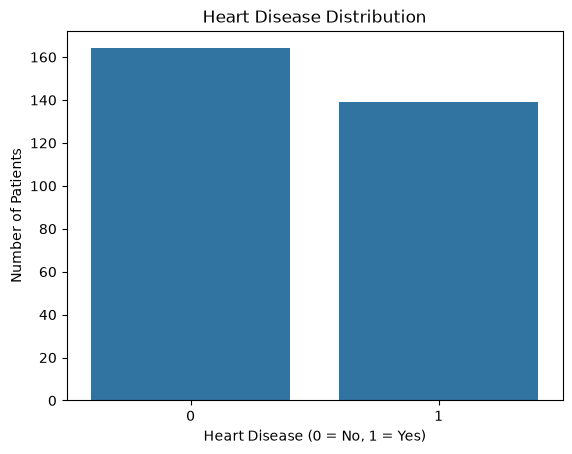

In [12]:
sns.countplot(x="target_binary", data=heart_df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

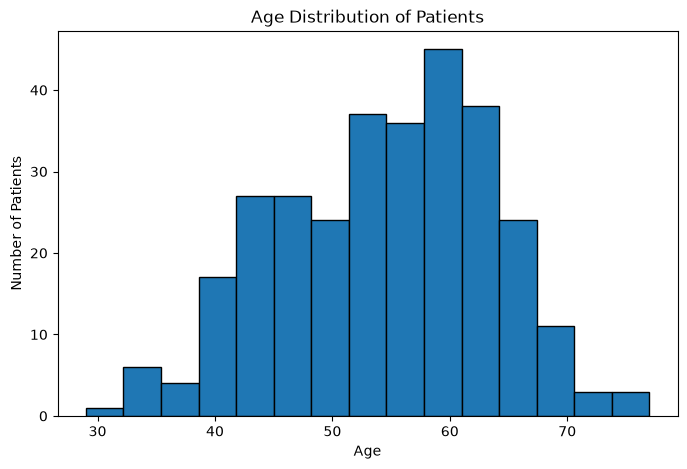

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    heart_df["age"],
    bins=15,
    edgecolor="black"
)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

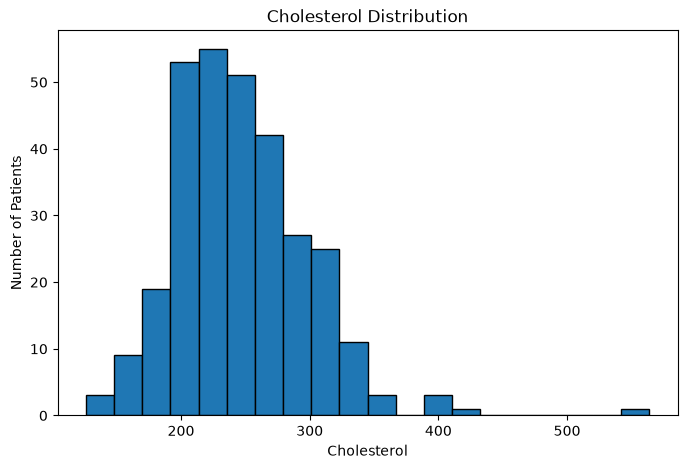

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    heart_df["chol"],
    bins=20,
    edgecolor="black"
)

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Number of Patients")

plt.show()

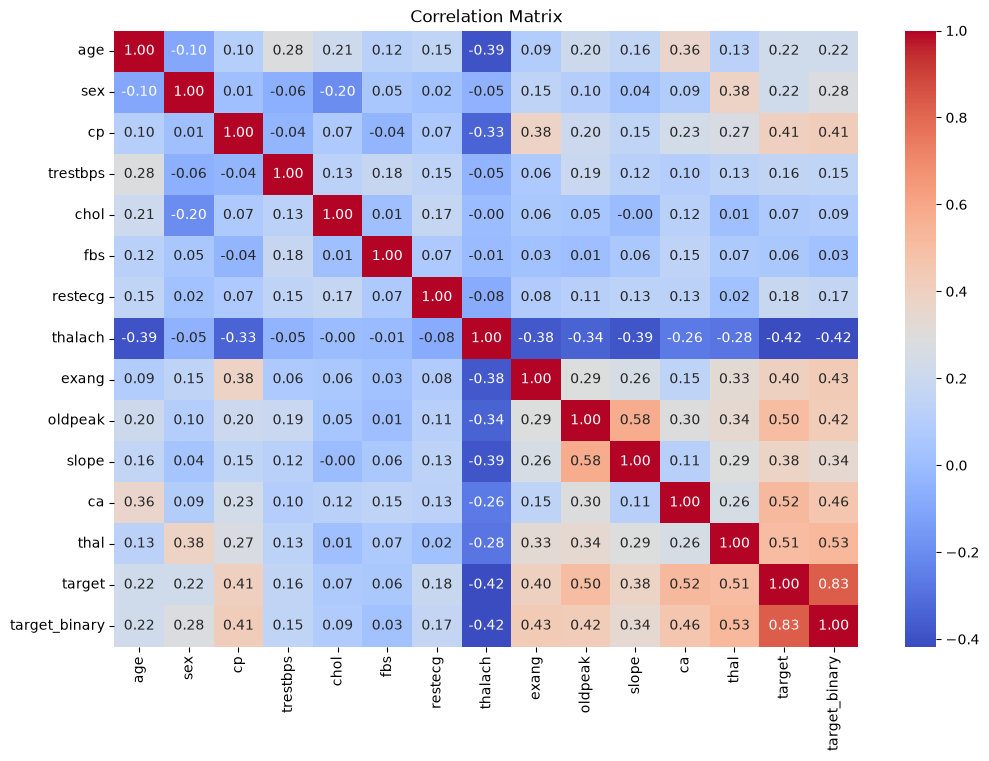

In [15]:
plt.figure(figsize=(12, 8))

correlation = heart_df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [16]:
X = heart_df.drop(
    columns=["target", "target_binary"]
)

y = heart_df["target_binary"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target:
target_binary


In [17]:
imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

X_imputed = pd.DataFrame(
    X_imputed,
    columns=X.columns
)

print("Missing values handled successfully.")
print(X_imputed.isnull().sum().sum())

Missing values handled successfully.
0


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (242, 13)
Testing data: (61, 13)


### Feature scaling

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### TRAINING REGRESSION MODEL

In [20]:
model = LogisticRegression(max_iter=1000)

model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [21]:
y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 4))


Accuracy: 0.8689


In [23]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC:", round(roc_auc, 4))

ROC AUC: 0.9513


In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[27  6]
 [ 2 26]]


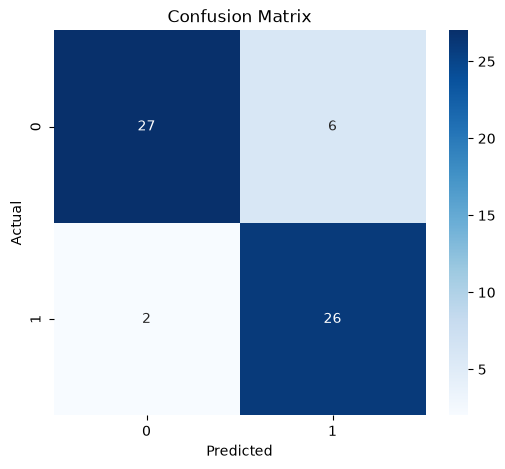

In [25]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



### Fetching The ECG record


In [28]:
record_name = "100"

record = wfdb.rdrecord(
    record_name,
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    record_name,
    "atr",
    pn_dir="mitdb"
)

print("ECG record fetched successfully!")
print("Signal shape:", record.p_signal.shape)
print("Sampling frequency:", record.fs)
print("Number of annotations:", len(annotation.sample))

ECG record fetched successfully!
Signal shape: (650000, 2)
Sampling frequency: 360
Number of annotations: 2274


In [29]:
print("Record name:", record_name)
print("Sampling frequency:", record.fs)
print("Number of samples:", record.sig_len)
print("Number of channels:", record.n_sig)
print("Channel names:", record.sig_name)

Record name: 100
Sampling frequency: 360
Number of samples: 650000
Number of channels: 2
Channel names: ['MLII', 'V5']


In [ ]:
## SAVING THE DATA LOCALLY
wfdb.wrsamp(
    "data/ecg/record_100",
    fs=record.fs,
    units=record.units,
    sig_name=record.sig_name,
    p_signal=record.p_signal
)

print("ECG signal saved locally.")

ECG signal saved locally.


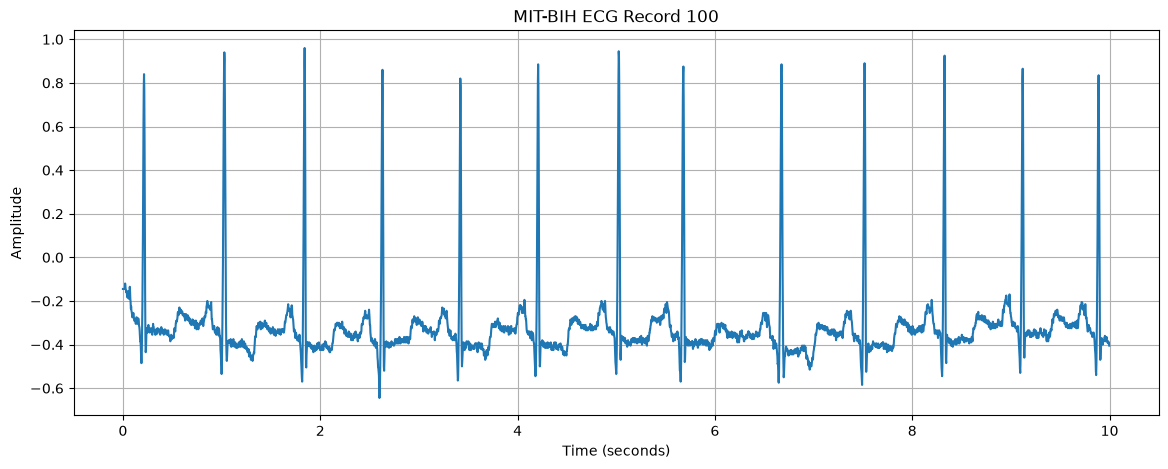

In [31]:
signal = record.p_signal[:, 0]

fs = record.fs

seconds = 10

samples = int(
    seconds * fs
)

time = np.arange(samples) / fs

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    signal[:samples]
)

plt.title("MIT-BIH ECG Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

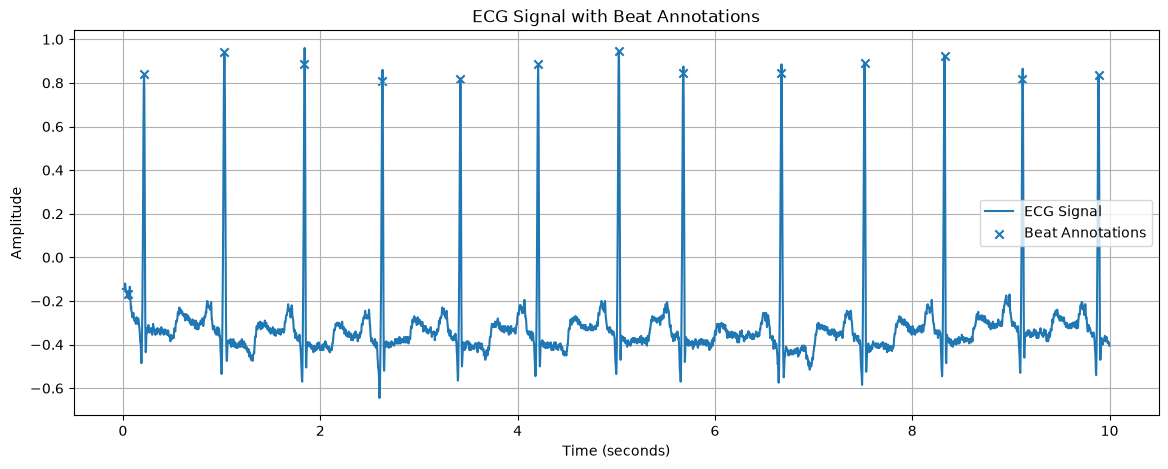

In [32]:
annotation_samples = annotation.sample

annotation_samples = annotation_samples[
    annotation_samples < samples
]

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    signal[:samples],
    label="ECG Signal"
)

plt.scatter(
    annotation_samples / fs,
    signal[annotation_samples],
    marker="x",
    label="Beat Annotations"
)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.legend()
plt.grid(True)

plt.show()

In [33]:
beat_samples = annotation.sample

beat_intervals = np.diff(beat_samples) / fs

print("First 10 beat intervals:")
print(beat_intervals[:10])

print("\nAverage beat interval:",
      round(np.mean(beat_intervals), 3),
      "seconds")

First 10 beat intervals:
[0.16388889 0.81388889 0.81111111 0.78888889 0.79166667 0.78888889
 0.81666667 0.65277778 0.99444444 0.84444444]

Average beat interval: 0.794 seconds


In [34]:
average_interval = np.mean(beat_intervals)

heart_rate = 60 / average_interval

print(
    "Approximate Average Heart Rate:",
    round(heart_rate, 2),
    "BPM"
)

Approximate Average Heart Rate: 75.54 BPM


In [35]:
print("Minimum beat interval:",
      round(np.min(beat_intervals), 3),
      "seconds")

print("Maximum beat interval:",
      round(np.max(beat_intervals), 3),
      "seconds")

print("Average beat interval:",
      round(np.mean(beat_intervals), 3),
      "seconds")

print("Standard deviation:",
      round(np.std(beat_intervals), 3),
      "seconds")

Minimum beat interval: 0.164 seconds
Maximum beat interval: 1.131 seconds
Average beat interval: 0.794 seconds
Standard deviation: 0.051 seconds


## PART 3 — TEXTUAL DATA

In [36]:
clinical_note = """
The patient is a 54 year old male who reports chest pain during exercise.
The patient also reports shortness of breath and mild fatigue.
Blood pressure is slightly elevated and cholesterol levels are high.
The patient was advised to follow up with a cardiologist.
"""

print(clinical_note)    


The patient is a 54 year old male who reports chest pain during exercise.
The patient also reports shortness of breath and mild fatigue.
Blood pressure is slightly elevated and cholesterol levels are high.
The patient was advised to follow up with a cardiologist.



In [37]:
with open(
    "data/text/clinical_note.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(clinical_note)

print("Clinical note saved successfully.")

Clinical note saved successfully.


In [38]:
import re

clean_text = clinical_note.lower()

clean_text = re.sub(
    r"[^a-z\s]",
    "",
    clean_text
)

print(clean_text)


the patient is a  year old male who reports chest pain during exercise
the patient also reports shortness of breath and mild fatigue
blood pressure is slightly elevated and cholesterol levels are high
the patient was advised to follow up with a cardiologist



In [39]:
words = clean_text.split()

print("First 20 tokens:")
print(words[:20])

print("\nTotal number of words:",
      len(words))

First 20 tokens:
['the', 'patient', 'is', 'a', 'year', 'old', 'male', 'who', 'reports', 'chest', 'pain', 'during', 'exercise', 'the', 'patient', 'also', 'reports', 'shortness', 'of', 'breath']

Total number of words: 43


In [40]:
stop_words = {
    "the", "is", "a", "of", "and",
    "to", "with", "was", "also",
    "who", "during"
}

filtered_words = [
    word for word in words
    if word not in stop_words
]

print(filtered_words)

['patient', 'year', 'old', 'male', 'reports', 'chest', 'pain', 'exercise', 'patient', 'reports', 'shortness', 'breath', 'mild', 'fatigue', 'blood', 'pressure', 'slightly', 'elevated', 'cholesterol', 'levels', 'are', 'high', 'patient', 'advised', 'follow', 'up', 'cardiologist']


In [41]:
word_frequency = Counter(filtered_words)

print("Most common words:")

for word, count in word_frequency.most_common(10):
    print(word, ":", count)

Most common words:
patient : 3
reports : 2
year : 1
old : 1
male : 1
chest : 1
pain : 1
exercise : 1
shortness : 1
breath : 1


In [42]:
word_frequency = Counter(filtered_words)

print("Most common words:")

for word, count in word_frequency.most_common(10):
    print(word, ":", count)

Most common words:
patient : 3
reports : 2
year : 1
old : 1
male : 1
chest : 1
pain : 1
exercise : 1
shortness : 1
breath : 1


In [43]:
medical_terms = [
    "chest",
    "pain",
    "exercise",
    "shortness",
    "breath",
    "fatigue",
    "blood",
    "pressure",
    "cholesterol",
    "cardiologist"
]

found_terms = [
    word
    for word in medical_terms
    if word in filtered_words
]

print("Key terms found in the clinical note:")
print(found_terms)

Key terms found in the clinical note:
['chest', 'pain', 'exercise', 'shortness', 'breath', 'fatigue', 'blood', 'pressure', 'cholesterol', 'cardiologist']


## PART 4 — IMAGE DATA

In [ ]:
image_array = np.zeros(
    (300, 400),
    dtype=np.uint8
)

y, x = np.ogrid[:300, :400]

center_x = 200
center_y = 150

radius = 100

circle = (
    (x - center_x) ** 2 +
    (y - center_y) ** 2
) <= radius ** 2

image_array[circle] = 180

image = Image.fromarray(
    image_array
)

image.save(
    "data/images/sample_medical_image.png"
)

print("Synthetic medical image created.")

Synthetic medical image created.


In [45]:
image = Image.open(
    "data/images/sample_medical_image.png"
)

print("Image loaded successfully.")
print("Image format:", image.format)
print("Image size:", image.size)
print("Image mode:", image.mode)

Image loaded successfully.
Image format: PNG
Image size: (400, 300)
Image mode: L


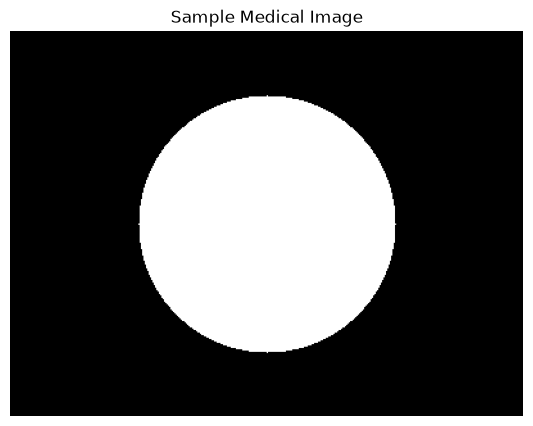

In [46]:
plt.figure(figsize=(7, 5))

plt.imshow(
    image,
    cmap="gray"
)

plt.title("Sample Medical Image")
plt.axis("off")

plt.show()

In [47]:
resized_image = image.resize(
    (200, 150)
)

print(
    "Original size:",
    image.size
)

print(
    "Resized size:",
    resized_image.size
)

Original size: (400, 300)
Resized size: (200, 150)


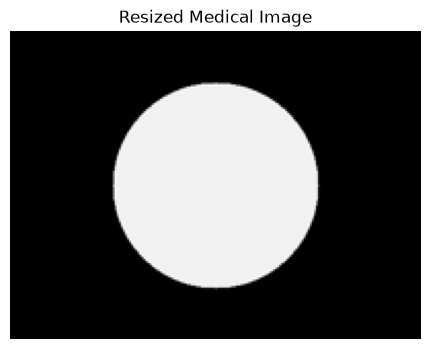

In [48]:
plt.figure(figsize=(6, 4))

plt.imshow(
    resized_image,
    cmap="gray"
)

plt.title("Resized Medical Image")
plt.axis("off")

plt.show()

In [49]:
print("========== DATA INGESTION SUMMARY ==========")

print("\n1. TABULAR DATA")
print("Dataset: UCI Cleveland Heart Disease")
print("Shape:", heart_df.shape)

print("\n2. MEDICAL DATA")
print("Patient health information from the Heart Disease dataset")
print("Records:", len(heart_df))

print("\n3. SIGNAL DATA")
print("Dataset: MIT-BIH Arrhythmia Database")
print("Record:", record_name)
print("Signal shape:", record.p_signal.shape)

print("\n4. TEXTUAL DATA")
print("Source: Synthetic clinical note")
print("Number of words:", len(words))

print("\n5. IMAGE DATA")
print("Source: Synthetic medical-style image")
print("Image size:", image.size)

print("\n=============================================")

========== DATA INGESTION SUMMARY ==========

1. TABULAR DATA
Dataset: UCI Cleveland Heart Disease
Shape: (303, 15)

2. MEDICAL DATA
Patient health information from the Heart Disease dataset
Records: 303

3. SIGNAL DATA
Dataset: MIT-BIH Arrhythmia Database
Record: 100
Signal shape: (650000, 2)

4. TEXTUAL DATA
Source: Synthetic clinical note
Number of words: 43

5. IMAGE DATA
Source: Synthetic medical-style image
Image size: (400, 300)

